In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from ripser import ripser
from persim import plot_diagrams
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings('ignore')

In [2]:
"""Import dataset"""

# Import data
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [3]:
"""Preprocess Data: Remove Duplicates and Missing Values"""

# Check initial counts
initial_count = X.shape[0]

# Remove duplicates
X_clean = X.drop_duplicates()
y_clean = y.loc[X_clean.index]
duplicates_removed = initial_count - X_clean.shape[0]

# Remove missing values
after_duplicates = X_clean.shape[0]
mask = ~X_clean.isnull().any(axis=1)
X_clean = X_clean[mask]
y_clean = y_clean[mask]
missing_removed = after_duplicates - X_clean.shape[0]

# Summary
print(f"Original shape: {initial_count}")
print(f"Duplicates removed: {duplicates_removed}")
print(f"Missing values removed: {missing_removed}")
print(f"Total removed: {duplicates_removed + missing_removed}")
print(f"Cleaned shape: {X_clean.shape[0]}")

# Update X and y
X = X_clean.reset_index(drop=True)
y = y_clean.reset_index(drop=True)

Original shape: 303
Duplicates removed: 0
Missing values removed: 6
Total removed: 6
Cleaned shape: 297


In [4]:
"""Standardize the Features"""

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns) # Convert back to DataFrame

In [5]:
"""Compute distance matrix"""

distance_matrices = {
    "euclidean": pairwise_distances(X_scaled, metric="euclidean"),
    "cityblock": pairwise_distances(X_scaled, metric="cityblock"),
    "chebyshev": pairwise_distances(X_scaled, metric="chebyshev"),
    "cosine": pairwise_distances(X_scaled, metric="cosine"),
}

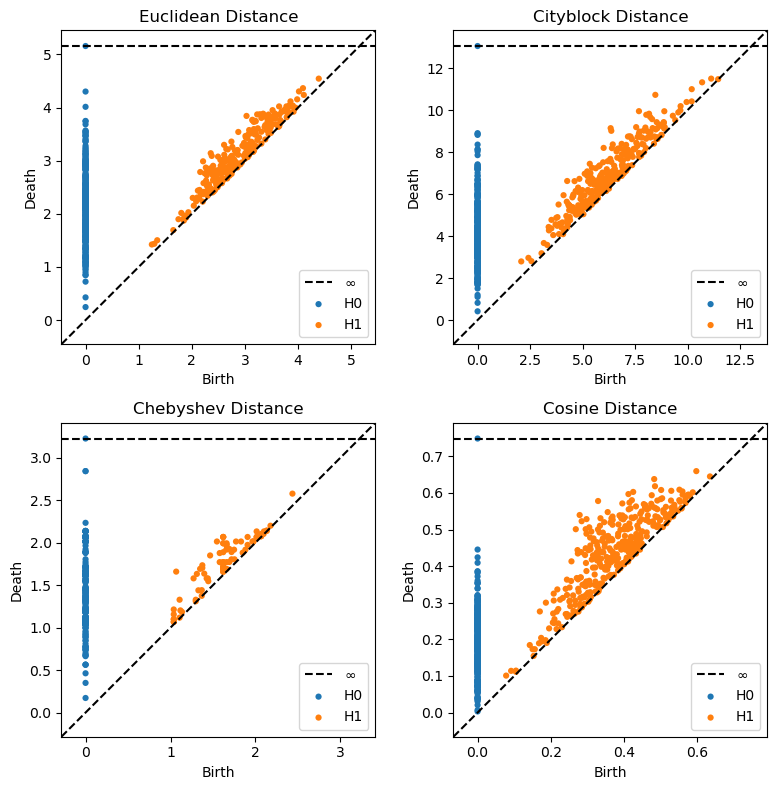

In [6]:
max_dimension = 1


fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for ax, (metric_name, D) in zip(axes, distance_matrices.items()):
    
    # Compute persistent homology (H0 + H1 only)
    result = ripser(D, maxdim=max_dimension, distance_matrix=True)
    diagrams = result["dgms"]   # diagrams = [H0, H1]
    
    # Plot H0 and H1 directly
    plot_diagrams(diagrams, labels=["H0", "H1"], ax=ax, show=False)
    
    # Title and labels
    ax.set_title(f"{metric_name.capitalize()} Distance")
    ax.set_xlabel("Birth")
    ax.set_ylabel("Death")

plt.tight_layout()
plt.show()


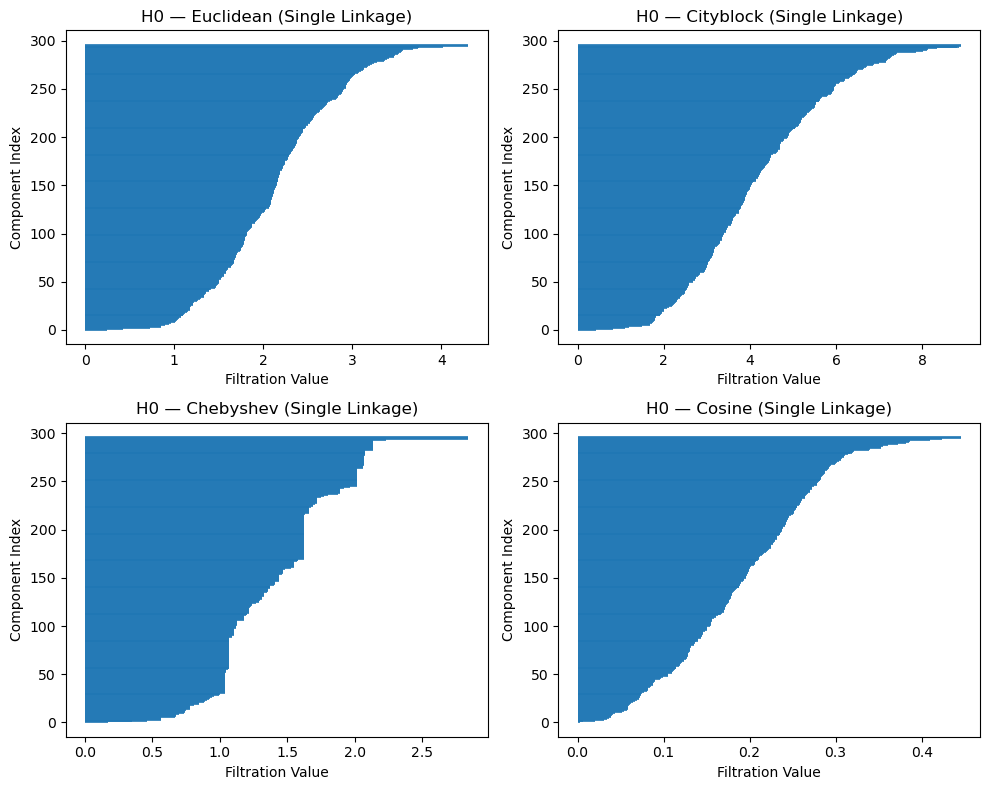

In [9]:


# ---------------------------------------------------------
# Prepare a 2×2 subplot figure
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# ---------------------------------------------------------
# Loop through metrics and plot H0 barcodes in subplots
# ---------------------------------------------------------
for ax, (metric_name, D) in zip(axes, distance_matrices.items()):
    
    # Convert to condensed form for linkage()
    condensed = squareform(D, checks=False)
    
    # Hierarchical clustering (single linkage)
    Z = linkage(condensed, method="single")
    
    # Extract merge heights = H0 death times
    merge_heights = Z[:, 2]
    
    # Births are always zero
    n = D.shape[0]
    births = np.zeros(n)
    deaths = np.append(merge_heights, np.inf)
    
    H0 = np.vstack([births, deaths]).T
    
    # Determine plotting max value
    finite_deaths = deaths[np.isfinite(deaths)]
    max_val = finite_deaths.max() if len(finite_deaths) else 1
    
    # Draw H0 barcode lines
    for i, (b, d) in enumerate(H0):
        if np.isinf(d):
            d = max_val
        ax.hlines(i, b, d, linewidth=1.2)
    
    # Title and labels
    ax.set_title(f"H0 — {metric_name.capitalize()} (Single Linkage)")
    ax.set_xlabel("Filtration Value")
    ax.set_ylabel("Component Index")

plt.tight_layout()
plt.show()


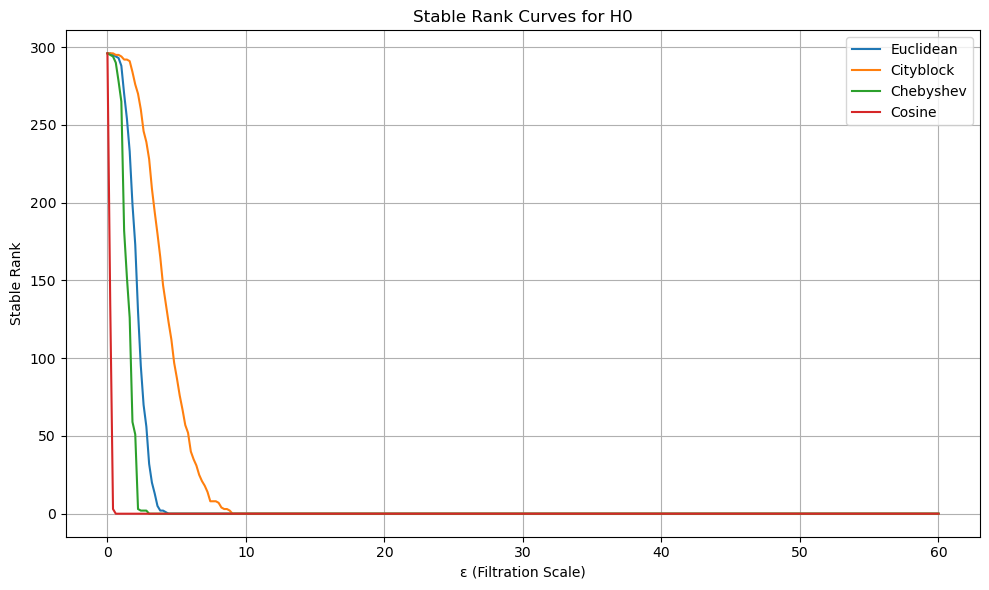

In [12]:

# ---------------------------------------------------------
# Compute H0 barcodes for all metrics (no functions)
# ---------------------------------------------------------
H0_results = {}   # store barcodes per metric

for metric_name, D in distance_matrices.items():

    condensed = squareform(D, checks=False)
    Z = linkage(condensed, method="single")

    merge_heights = Z[:, 2]

    n = D.shape[0]
    births = np.zeros(n)
    deaths = np.append(merge_heights, np.inf)

    H0 = np.vstack([births, deaths]).T
    H0_results[metric_name] = H0


# Extract H0 results (matching the same metric names!)
H0_euclidean = H0_results["euclidean"]
H0_cityblock = H0_results["cityblock"]
H0_chebyshev = H0_results["chebyshev"]
H0_cosine    = H0_results["cosine"]


# ---------------------------------------------------------
# Stable Rank (no functions)
# ---------------------------------------------------------
eps_values = np.linspace(0, 60, 300)

# Extract finite deaths
deaths_euclidean = H0_euclidean[:,1][np.isfinite(H0_euclidean[:,1])]
deaths_cityblock = H0_cityblock[:,1][np.isfinite(H0_cityblock[:,1])]
deaths_chebyshev = H0_chebyshev[:,1][np.isfinite(H0_chebyshev[:,1])]
deaths_cosine    = H0_cosine[:,1][np.isfinite(H0_cosine[:,1])]

# Stable rank curves
sr_euclidean = [np.sum(deaths_euclidean > eps) for eps in eps_values]
sr_cityblock = [np.sum(deaths_cityblock > eps) for eps in eps_values]
sr_chebyshev = [np.sum(deaths_chebyshev > eps) for eps in eps_values]
sr_cosine    = [np.sum(deaths_cosine > eps)    for eps in eps_values]

sr_euclidean = np.array(sr_euclidean)
sr_cityblock = np.array(sr_cityblock)
sr_chebyshev = np.array(sr_chebyshev)
sr_cosine    = np.array(sr_cosine)


# ---------------------------------------------------------
# Plot stable rank curves
# ---------------------------------------------------------
plt.figure(figsize=(10,6))

plt.plot(eps_values, sr_euclidean, label="Euclidean")
plt.plot(eps_values, sr_cityblock, label="Cityblock")
plt.plot(eps_values, sr_chebyshev, label="Chebyshev")
plt.plot(eps_values, sr_cosine, label="Cosine")

plt.title("Stable Rank Curves for H0")
plt.xlabel("ε (Filtration Scale)")
plt.ylabel("Stable Rank")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


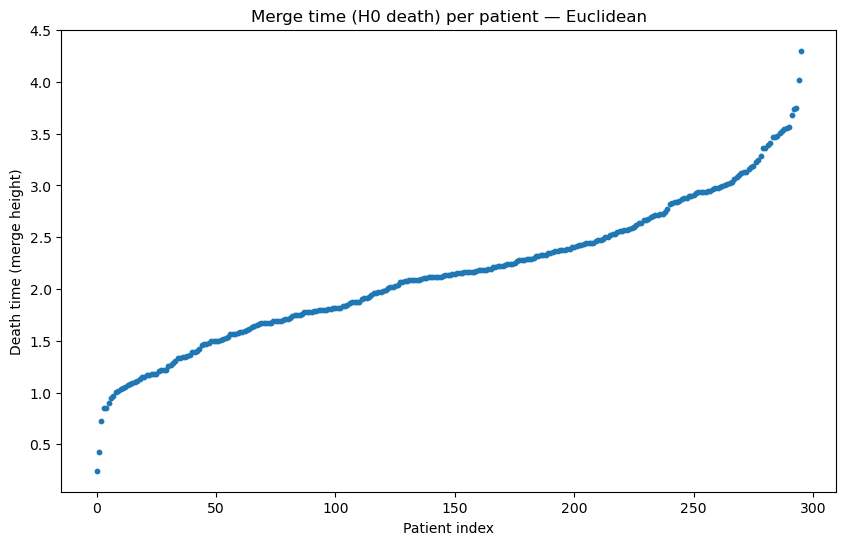

In [13]:
plt.figure(figsize=(10,6))

deaths = H0_euclidean[:,1]
finite = deaths[np.isfinite(deaths)]

plt.scatter(np.arange(len(finite)), finite, s=10)
plt.title("Merge time (H0 death) per patient — Euclidean")
plt.xlabel("Patient index")
plt.ylabel("Death time (merge height)")
plt.show()


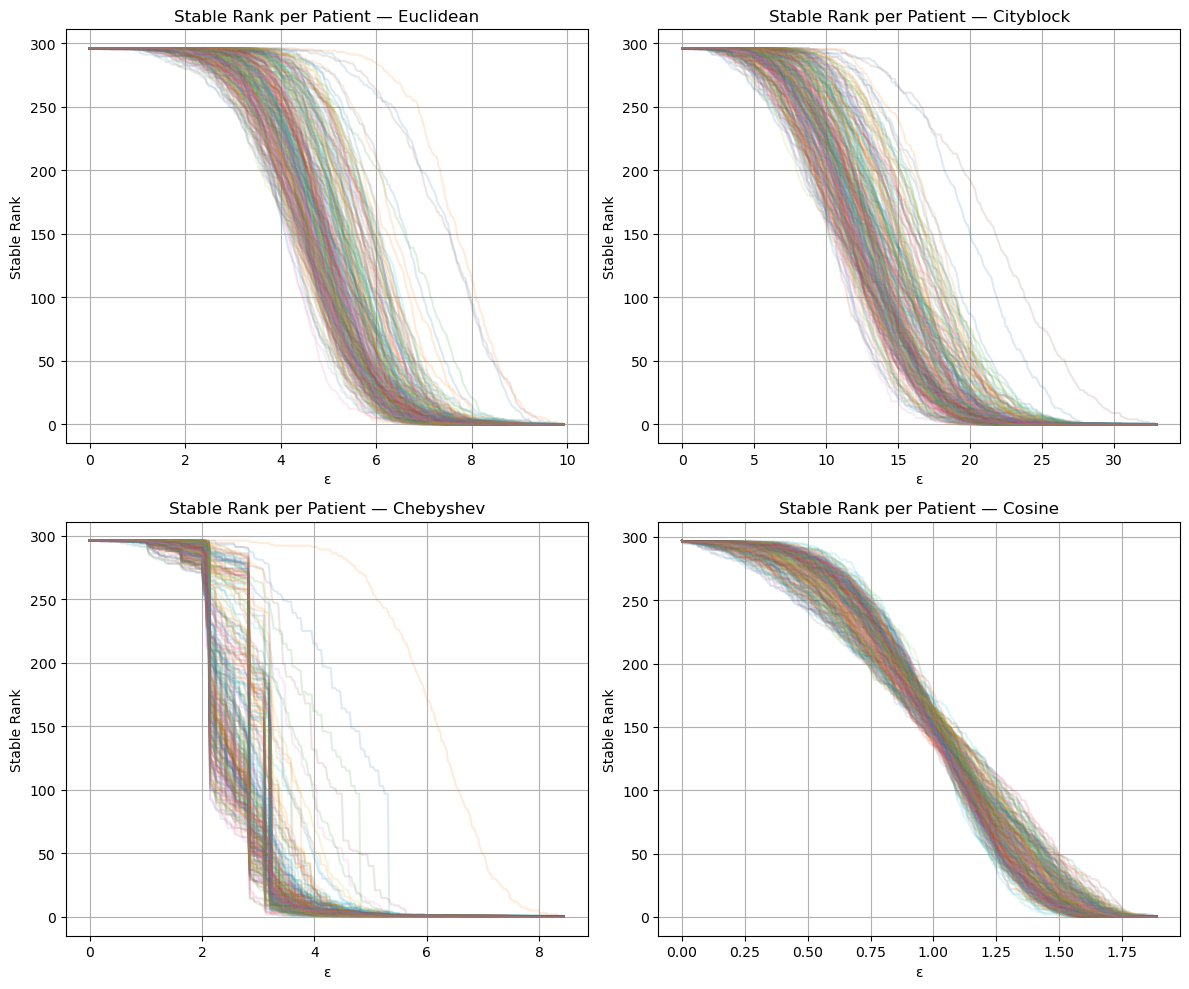

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()

for ax, (metric_name, D) in zip(axes, distance_matrices.items()):
    
    n = D.shape[0]
    eps_values = np.linspace(0, np.max(D), 300)
    
    for i in range(n):
        dist_vec = D[i]
        sr = [np.sum(dist_vec > eps) for eps in eps_values]
        ax.plot(eps_values, sr, alpha=0.15)
    
    ax.set_title(f"Stable Rank per Patient — {metric_name.capitalize()}")
    ax.set_xlabel("ε")
    ax.set_ylabel("Stable Rank")
    ax.grid(True)

plt.tight_layout()
plt.show()


Random Forest — Raw Data
Binary Classification Accuracy: 88.33%
Multi-Class Classification Accuracy: 60.00%


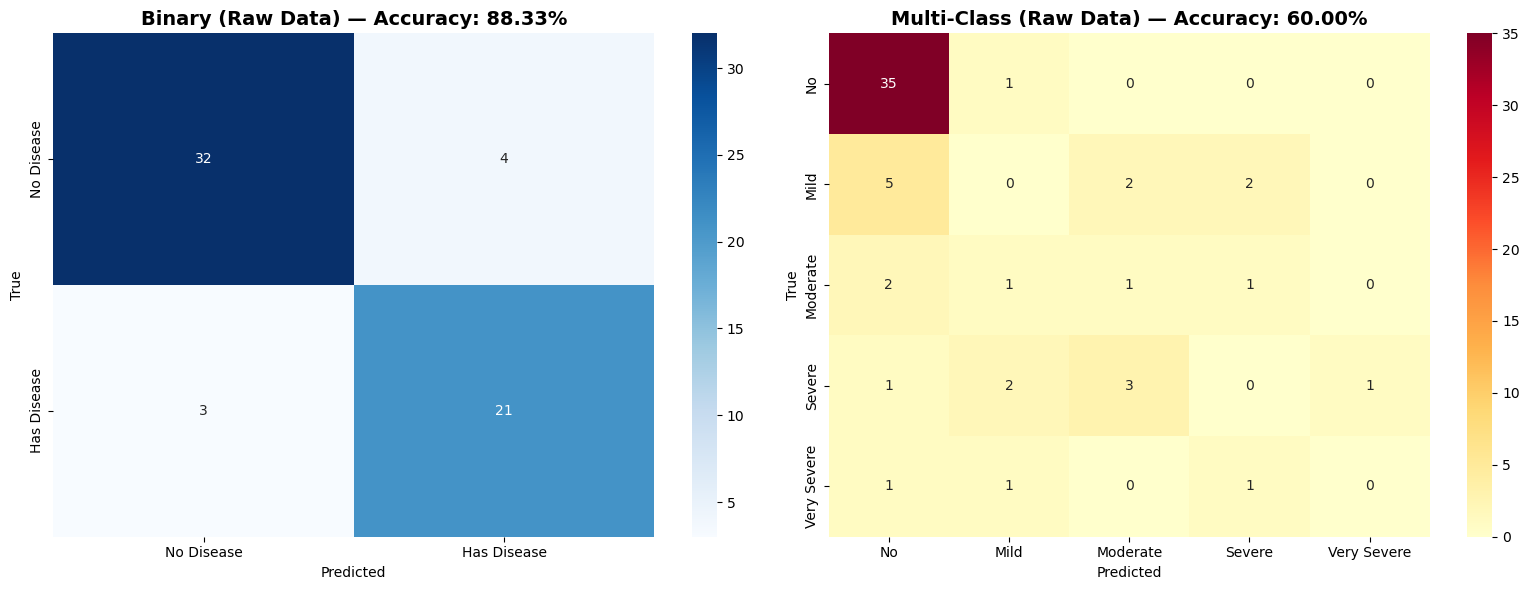

In [9]:
"""Random Forest Classification Using Raw Data"""

# Binary classification (y > 0 = has disease)
y_binary = (y > 0).astype(int)

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_scaled, y_binary, test_size=0.2, random_state=42
)

clf_bin = RandomForestClassifier(n_estimators=100, random_state=42)
clf_bin.fit(X_train_bin, y_train_bin)
y_pred_bin = clf_bin.predict(X_test_bin)
acc_bin = accuracy_score(y_test_bin, y_pred_bin)

# Multi-class classification (0–4 severity)
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

clf_multi = RandomForestClassifier(n_estimators=100, random_state=42)
clf_multi.fit(X_train_multi, y_train_multi)
y_pred_multi = clf_multi.predict(X_test_multi)
acc_multi = accuracy_score(y_test_multi, y_pred_multi)

# Print results
print("Random Forest — Raw Data")
print(f"Binary Classification Accuracy: {acc_bin:.2%}")
print(f"Multi-Class Classification Accuracy: {acc_multi:.2%}")

# Plot confusion matrices 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Binary
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Disease', 'Has Disease'],
            yticklabels=['No Disease', 'Has Disease'],
            ax=axes[0])
axes[0].set_title(f'Binary (Raw Data) — Accuracy: {acc_bin:.2%}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# Multi-class
cm_multi = confusion_matrix(y_test_multi, y_pred_multi)
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='YlOrRd', cbar=True,
            xticklabels=['No', 'Mild', 'Moderate', 'Severe', 'Very Severe'],
            yticklabels=['No', 'Mild', 'Moderate', 'Severe', 'Very Severe'],
            ax=axes[1])
axes[1].set_title(f'Multi-Class (Raw Data) — Accuracy: {acc_multi:.2%}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()
